# 02 — Análise exploratória e alavancas de receita

Cinco perguntas para serem respondidas: sazonalidade, categorias, delivery e recompra, CLV regional e concentração de sellers. 

Receita significa preço dos itens; pedidos `canceled`/`unavailable` são excluídos. Agosto/2018 é parcial.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from ifood_analytics.analysis import bootstrap_clustered_mean_difference
DATA = Path('../data/gold')
sns.set_theme(style='whitegrid')
orders = pd.read_parquet(DATA / 'fact_orders.parquet')
items = pd.read_parquet(DATA / 'fact_order_items.parquet')
con = duckdb.connect()
con.register('fact_orders', orders)
con.register('fact_order_items', items)


## 1. Qual é a sazonalidade?
A série cresce ao longo da expansão da plataforma; 

novembro/2017 é o pico, compatível com Black Friday. 

A comparação por mês do calendário usa apenas 2017 e meses completos de 2018 para reduzir a mistura entre tendência e sazonalidade.

In [36]:
monthly = con.sql("""
    SELECT date_trunc('month', order_purchase_timestamp) AS pedidos_mes,
           COUNT(DISTINCT order_id) AS orders, SUM(item_revenue) AS receita,
           SUM(item_revenue) / COUNT(DISTINCT order_id) AS valor_medio_pedido
    FROM fact_orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1 ORDER BY 1
""").df()

In [45]:
yoy = monthly.pivot(index='month', columns='year', values='orders').dropna(subset=[2017, 2018])
yoy['2018_x_2017'] = yoy[2018] / yoy[2017] - 1
display(yoy.style.format({2017:'{:,.0f}', 2018:'{:,.0f}', '2018_x_2017':'{:.1%}'}))

yoy = monthly.pivot(index='month', columns='year', values='receita').dropna(subset=[2017, 2018])
yoy['2018_x_2017'] = yoy[2018] / yoy[2017] - 1
yoy.style.format({2017:'R$ {:,.0f}', 2018:'R$ {:,.0f}', '2018_x_2017':'{:.1%}'})

year,2016,2017,2018,2018_x_2017
month,,,,
1,nan,787,"7,187",813.2%
2,nan,"1,718","6,625",285.6%
3,nan,"2,617","7,168",173.9%
4,nan,"2,377","6,919",191.1%
5,nan,"3,640","6,833",87.7%
6,nan,"3,205","6,145",91.7%
7,nan,"3,946","6,233",58.0%
8,nan,"4,272","6,421",50.3%
9,2.000000,"4,227",1,-100.0%


year,2016,2017,2018,2018_x_2017
month,,,,
1,nan,"R$ 120,098","R$ 945,456",687.2%
2,nan,"R$ 244,959","R$ 837,895",242.1%
3,nan,"R$ 368,341","R$ 981,051",166.3%
4,nan,"R$ 353,843","R$ 993,593",180.8%
5,nan,"R$ 503,159","R$ 992,872",97.3%
6,nan,"R$ 429,917","R$ 863,266",100.8%
7,nan,"R$ 492,287","R$ 878,044",78.4%
8,nan,"R$ 568,246","R$ 848,860",49.4%
9,207.860000,"R$ 621,416",R$ 145,-100.0%


,pedidos_mes,orders,receita,valor_medio_pedido
13,2017-11-01,7423,1003862.14,135.236716
18,2018-04-01,6919,993592.98,143.603553
19,2018-05-01,6833,992871.75,145.305393
17,2018-03-01,7168,981051.06,136.865382
15,2018-01-01,7187,945456.29,131.550896


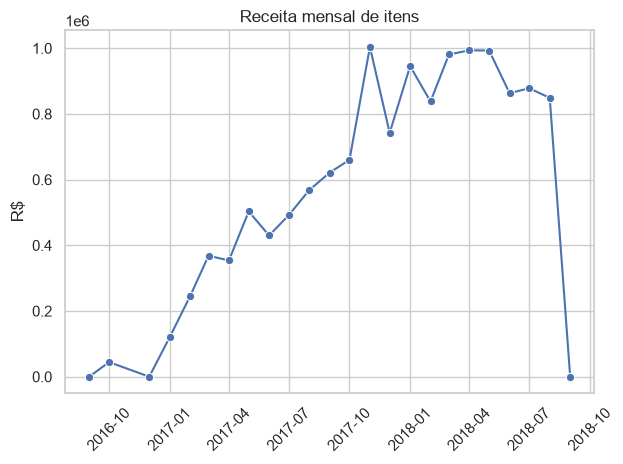

In [49]:
ax = sns.lineplot(data=monthly, x='pedidos_mes', y='receita', marker='o')
ax.set(title='Receita mensal de itens', xlabel='', ylabel='R$'); plt.xticks(rotation=45); plt.tight_layout()

display(monthly.nlargest(5, 'receita')[['pedidos_mes', 'orders', 'receita', 'valor_medio_pedido']])
complete = monthly[(monthly.pedidos_mes >= '2017-01-01') & (monthly.pedidos_mes < '2018-08-01')].copy()
complete['mes'] = complete.pedidos_mes.dt.month

In [51]:
display(complete.groupby('mes').agg(receita_media=('receita','mean'), anos_observados=('pedidos_mes','size')))
monthly['year'] = monthly.pedidos_mes.dt.year; monthly['month'] = monthly.pedidos_mes.dt.month

,receita_media,anos_observados
mes,,
1,532777.280,2
2,541427.390,2
3,674696.190,2
4,673717.980,2
5,748015.470,2
6,646591.070,2
7,685165.785,2
8,568245.790,1
9,621415.910,1


## 2. Quais categorias são mais rentáveis?
A base não contém custos: usamos receita como proxy, declaradamente. As análises abaixo filtram março–agosto/2018 para alinhar com o recorte executivo do one-pager. As cinco líderes concentram **40,8%** do GMV no período.


In [57]:
category = con.sql("""
    SELECT category, COUNT(DISTINCT order_id) AS pedidos, 
        SUM(price) AS receita,
        ROUND(SUM(price) / COUNT(DISTINCT order_id), 2) AS ticket_medio,
        AVG(review_score) AS nota_media, 
        AVG(CAST(is_late AS INTEGER)) AS taxa_atraso
    FROM fact_order_items
    WHERE order_status NOT IN ('canceled', 'unavailable')
      AND order_purchase_timestamp >= '2018-03-01'
      AND order_purchase_timestamp < '2018-09-01'
    GROUP BY 1 ORDER BY receita DESC LIMIT 10
""").df()
category[['category', 'pedidos', 'receita', 'ticket_medio', 'nota_media', 'taxa_atraso']]


,category,pedidos,receita,ticket_medio,nota_media,taxa_atraso
0,health_beauty,4206,611250.54,145.33,4.195959,0.104112
1,watches_gifts,2839,569767.52,200.69,4.032122,0.086868
2,bed_bath_table,3611,400736.05,110.98,3.949056,0.079039
3,sports_leisure,2872,363504.92,126.57,4.153436,0.084257
4,housewares,2742,324766.59,118.44,4.084694,0.071584
5,computers_accessories,2649,320378.92,120.94,4.041082,0.081364
6,furniture_decor,2372,292103.26,123.15,3.969970,0.081411
7,auto,1903,269160.11,141.44,4.145967,0.088088
8,baby,1279,200158.78,156.50,4.074060,0.078358
9,garden_tools,1096,160812.26,146.73,4.139955,0.094697


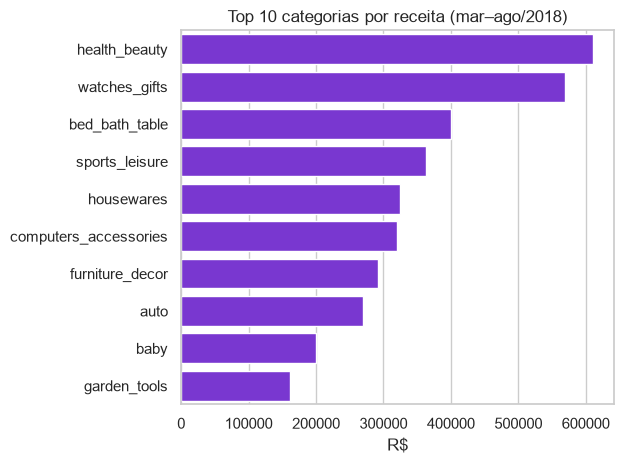

In [56]:
sns.barplot(data=category, y='category', x='receita', color="#761DEA").set(title='Top 10 categorias por receita (mar–ago/2018)', xlabel='R$', ylabel=''); plt.tight_layout()

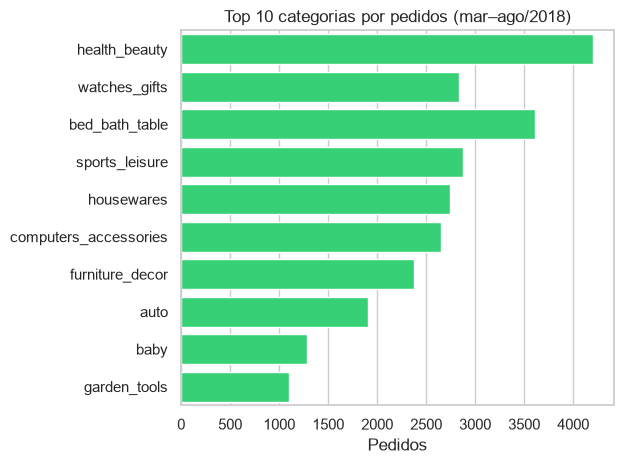

In [59]:
sns.barplot(data=category, y='category', x='pedidos', color="#1DEA72").set(title='Top 10 categorias por pedidos (mar–ago/2018)', xlabel='Pedidos', ylabel=''); plt.tight_layout()

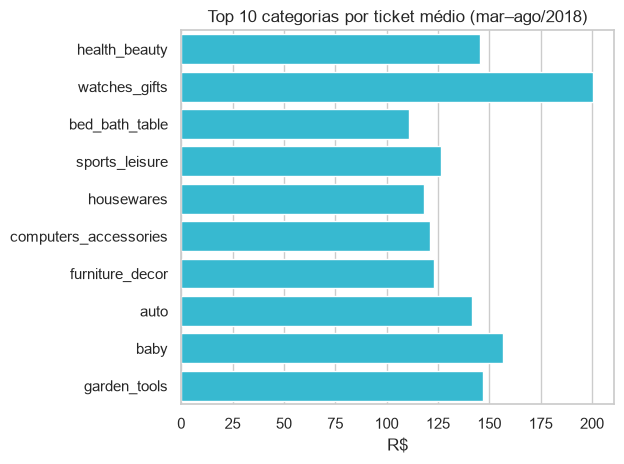

In [58]:
sns.barplot(data=category, y='category', x='ticket_medio', color="#1DCBEA").set(title='Top 10 categorias por ticket médio (mar–ago/2018)', xlabel='R$', ylabel=''); plt.tight_layout()

### Profundidade: concentração, frete e qualidade por categoria
Receita sozinha pode privilegiar categorias com experiência ruim ou frete pesado. A matriz abaixo adiciona participação, ticket por pedido, peso do frete e qualidade operacional.

Entre as categorias de maior receita, `bed_bath_table` combina review abaixo de 4,0 com frete equivalente a 19,7% da receita; `furniture_decor` chega a 23,7%. Isso sugere separar cross-sell de ações de eficiência logística: escalar demanda sem tratar frete/experiência pode deteriorar valor.

In [65]:
category_full = con.sql("""
    SELECT category AS categoria, 
        COUNT(DISTINCT order_id) AS pedidos, 
        SUM(price) AS receita,
        ROUND(SUM(freight_value), 2) AS frete,
        AVG(review_score) AS nota_media,
        AVG(CAST(is_late AS INTEGER)) AS taxa_atraso
    FROM fact_order_items
    WHERE order_status NOT IN ('canceled','unavailable')
      AND order_purchase_timestamp >= '2018-03-01'
      AND order_purchase_timestamp < '2018-09-01'
    GROUP BY 1
""").df()

,categoria,pedidos,receita,frete,nota_media,taxa_atraso,receita_share,ticket_medio,frete_sobre_receita
49,health_beauty,4206,"R$ 611,251",90828.320000,4.20,10.4%,11.0%,R$ 145.33,14.9%
19,watches_gifts,2839,"R$ 569,768",51176.190000,4.03,8.7%,10.3%,R$ 200.69,9.0%
67,bed_bath_table,3611,"R$ 400,736",86867.520000,3.95,7.9%,7.2%,R$ 110.98,21.7%
68,sports_leisure,2872,"R$ 363,505",63668.520000,4.15,8.4%,6.5%,R$ 126.57,17.5%
57,housewares,2742,"R$ 324,767",74744.640000,4.08,7.2%,5.8%,R$ 118.44,23.0%
0,computers_accessories,2649,"R$ 320,379",58934.650000,4.04,8.1%,5.8%,R$ 120.94,18.4%
48,furniture_decor,2372,"R$ 292,103",69175.100000,3.97,8.1%,5.3%,R$ 123.15,23.7%
8,auto,1903,"R$ 269,160",44744.520000,4.15,8.8%,4.8%,R$ 141.44,16.6%
41,baby,1279,"R$ 200,159",33737.240000,4.07,7.8%,3.6%,R$ 156.50,16.9%
22,garden_tools,1096,"R$ 160,812",31381.070000,4.14,9.5%,2.9%,R$ 146.73,19.5%


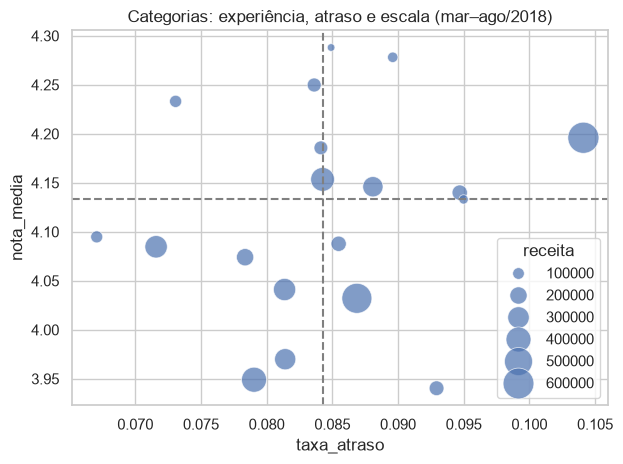

In [66]:
category_full['receita_share'] = category_full.receita / category_full.receita.sum()
category_full['ticket_medio'] = category_full.receita / category_full.pedidos
category_full['frete_sobre_receita'] = category_full.frete / category_full.receita
display(category_full.nlargest(10,'receita').style.format({'receita':'R$ {:,.0f}','receita_share':'{:.1%}','ticket_medio':'R$ {:.2f}','frete_sobre_receita':'{:.1%}','nota_media':'{:.2f}','taxa_atraso':'{:.1%}'}))
focus = category_full[category_full.pedidos >= 500]
sns.scatterplot(data=focus, x='taxa_atraso', y='nota_media', size='receita', sizes=(30,500), alpha=.7)
plt.axvline(focus.taxa_atraso.median(), color='gray', ls='--'); plt.axhline(focus.nota_media.median(), color='gray', ls='--'); plt.title('Categorias: experiência, atraso e escala (mar–ago/2018)'); plt.tight_layout()


## 3. Delivery afeta recompra?
Comparamos pedidos entregues no prazo/atrasados e marcamos se houve pedido posterior do mesmo `customer_unique_id`. É associação observacional, sujeita a censura temporal e confundidores.

Atrasados: recompra 2,72% vs 3,31% e review 2,57 vs 4,29. A diferença de recompra é −0,59 p.p. (IC95% bootstrap agrupado por `customer_unique_id`: −0,97 a −0,20 p.p.). Mesmo com intervalo abaixo de zero, o desenho observacional não elimina censura temporal ou confundidores; o resultado justifica experimento de SLA/recuperação, não promessa causal.

In [68]:
delivered = orders.query("order_status == 'delivered'").sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
position = delivered.groupby('customer_unique_id').cumcount()
size = delivered.groupby('customer_unique_id').order_id.transform('size')
delivered['has_next_order'] = position < size - 1
delivery = delivered.dropna(subset=['is_late']).groupby('is_late').agg(orders=('order_id','size'), repeat_rate=('has_next_order','mean'), review=('review_score','mean'), delivery_days=('delivery_days','mean'))
display(delivery.style.format({'repeat_rate':'{:.2%}', 'review':'{:.2f}', 'delivery_days':'{:.1f}'}))
# Bootstrap agrupado por customer_unique_id: pedidos do mesmo cliente são correlacionados.
eligible_for_bootstrap = delivered.dropna(subset=['is_late']).copy()
eligible_for_bootstrap['has_next_order'] = eligible_for_bootstrap['has_next_order'].astype(float)
difference, ci_low, ci_high = bootstrap_clustered_mean_difference(
    eligible_for_bootstrap,
    cluster_column='customer_unique_id',
    group_column='is_late',
    value_column='has_next_order',
    group_a=True,
    group_b=False,
)
pd.Series({'diferença_atrasado_menos_prazo': difference, 'IC95%_inferior': ci_low, 'IC95%_superior': ci_high}).to_frame('taxa')


,orders,repeat_rate,review,delivery_days
is_late,,,,
False,88644,3.28%,4.29,10.8
True,7826,2.71%,2.57,31.5


,taxa
diferença_atrasado_menos_prazo,-0.005716
IC95%_inferior,-0.009488
IC95%_superior,-0.001902


### Robustez: mesma janela de oportunidade de recompra
Pedidos perto do fim da base tiveram menos tempo para recomprar. A análise de sensibilidade restringe a coorte a compras com pelo menos 90 dias de observação e mede recompra nos 90 dias seguintes.

**Resultado da sensibilidade:** com janela de 90 dias, a diferença cai para −0,29 p.p. e o IC95% vai de −0,64 a +0,08 p.p., cruzando zero. 

A evidência de efeito sobre recompra é frágil;

A queda expressiva de review permanece o sinal mais robusto para priorizar um experimento logístico.

In [6]:
valid_orders = orders[orders.order_status.eq('delivered')].sort_values(['customer_unique_id','order_purchase_timestamp']).copy()
valid_orders['next_purchase_at'] = valid_orders.groupby('customer_unique_id').order_purchase_timestamp.shift(-1)
valid_orders['repurchase_90d'] = (valid_orders.next_purchase_at - valid_orders.order_purchase_timestamp).dt.days.between(0,90)
cutoff = valid_orders.order_purchase_timestamp.max() - pd.Timedelta(days=90)
eligible = valid_orders[(valid_orders.order_purchase_timestamp <= cutoff) & valid_orders.is_late.notna()].copy()
sensitivity = eligible.groupby('is_late').agg(orders=('order_id','size'), repurchase_90d=('repurchase_90d','mean'), review=('review_score','mean'))
display(sensitivity.style.format({'repurchase_90d':'{:.2%}','review':'{:.2f}'}))
# Bootstrap agrupado por cliente para consistência metodológica com a análise principal.
eligible['repurchase_90d'] = eligible['repurchase_90d'].astype(float)
diff90, low90, high90 = bootstrap_clustered_mean_difference(
    eligible,
    cluster_column='customer_unique_id',
    group_column='is_late',
    value_column='repurchase_90d',
    group_a=True,
    group_b=False,
)
pd.Series({'difference_90d':diff90,'IC95%_lower':low90,'IC95%_upper':high90,'eligible_until':cutoff}).to_frame('value')


,orders,repurchase_90d,review
is_late,,,
False,70991,2.51%,4.28
True,6806,2.23%,2.45


,value
difference_90d,-0.002754
IC95%_lower,-0.006465
IC95%_upper,0.001027
eligible_until,2018-05-31 15:00:37


## 4. Como varia o CLV por região?
CLV é receita histórica observada por cliente, porque a janela curta não sustenta um modelo de lifetime futuro.

**Insights**
- SP lidera por escala; 
- RJ/MG completam o maior pool acionável. 
- CLV médio isolado não basta para priorizar UFs pequenas.
- Estados pequenos podem ter CLV médio alto por ruído amostral. 
- A comparação inclui índice contra a média nacional e restringe a visualização a estados com pelo menos 500 clientes.
- SP concentra escala, mas seu CLV médio fica em 0,91× a média nacional. RJ está em 1,04× e BA em 1,10×, embora com bases menores. 
- A decisão de investimento deve combinar tamanho do pool, custo de aquisição e margem; CLV médio isolado favoreceria indevidamente estados pequenos.

In [7]:
clv = pd.read_parquet(DATA / 'mart_customer_value.parquet')
region = clv.groupby('customer_state').agg(customers=('customer_unique_id','nunique'), revenue=('observed_clv','sum'), avg_clv=('observed_clv','mean'), repeat_rate=('is_repeat_customer','mean')).sort_values('revenue', ascending=False)
region.head(10).style.format({'revenue':'R$ {:,.0f}', 'avg_clv':'R$ {:,.2f}', 'repeat_rate':'{:.2%}'})

,customers,revenue,avg_clv,repeat_rate
customer_state,,,,
SP,39743,"R$ 5,165,053",R$ 129.96,3.15%
RJ,12238,"R$ 1,811,476",R$ 148.02,3.37%
MG,11129,"R$ 1,573,519",R$ 141.39,2.97%
RS,5233,"R$ 742,640",R$ 141.91,3.13%
PR,4824,"R$ 676,978",R$ 140.34,2.96%
SC,3497,"R$ 517,971",R$ 148.12,2.66%
BA,3243,"R$ 507,062",R$ 156.36,2.81%
DF,2056,"R$ 300,285",R$ 146.05,2.97%
GO,1933,"R$ 288,755",R$ 149.38,3.16%


,customer_state,customers,revenue,avg_clv,repeat_rate,clv_index,revenue_share
0,SP,39743,"R$ 5,165,053",R$ 129.96,3.15%,0.91x,38.3%
1,RJ,12238,"R$ 1,811,476",R$ 148.02,3.37%,1.04x,13.4%
2,MG,11129,"R$ 1,573,519",R$ 141.39,2.97%,1.00x,11.7%
3,RS,5233,"R$ 742,640",R$ 141.91,3.13%,1.00x,5.5%
4,PR,4824,"R$ 676,978",R$ 140.34,2.96%,0.99x,5.0%
5,SC,3497,"R$ 517,971",R$ 148.12,2.66%,1.04x,3.8%
6,BA,3243,"R$ 507,062",R$ 156.36,2.81%,1.10x,3.8%
7,DF,2056,"R$ 300,285",R$ 146.05,2.97%,1.03x,2.2%
8,GO,1933,"R$ 288,755",R$ 149.38,3.16%,1.05x,2.1%
9,ES,1950,"R$ 273,622",R$ 140.32,2.97%,0.99x,2.0%


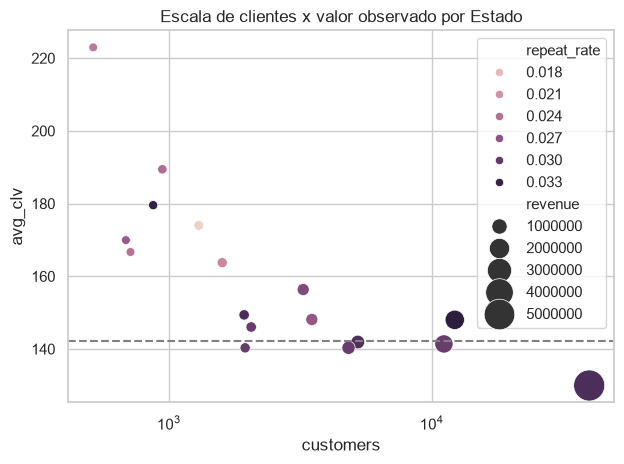

In [ ]:
national_clv = clv.observed_clv.mean()
region['clv_index'] = region.avg_clv / national_clv
region['revenue_share'] = region.revenue / region.revenue.sum()
reliable_region = region[region.customers >= 500].reset_index()
display(reliable_region.style.format({'revenue':'R$ {:,.0f}','avg_clv':'R$ {:.2f}','repeat_rate':'{:.2%}','clv_index':'{:.2f}x','revenue_share':'{:.1%}'}))
sns.scatterplot(data=reliable_region, x='customers', y='avg_clv', size='revenue', hue='repeat_rate', sizes=(40,500))
plt.axhline(national_clv, color='gray', ls='--'); plt.xscale('log'); plt.title('Escala de clientes x valor observado por Estado'); plt.tight_layout()

## 5. Há concentração de sellers?
Curva acumulada, HHI e Gini distinguem concentração operacional, desigualdade da cauda e dominância individual.
- HHI mede dominância
- Gini mede desigualdade da distribuição. 
- A matriz receita × atraso identifica sellers relevantes para gestão de SLA, sem confundir concentração com monopólio.

> Top 10% dos sellers geram 67,5% da receita e o Gini de 0,79 confirma forte desigualdade na cauda; ao mesmo tempo, HHI de 0,0036 e top seller com 1,7% indicam ausência de monopolista.

> Entre sellers com 30+ pedidos, o atraso ponderado por receita é 7,9%, permitindo priorizar SLAs por impacto. 

> As alavancas recomendadas continuam sendo disponibilidade/cross-sell nas categorias líderes, aquisição mensurável em SP/RJ/MG e confiabilidade logística — mas a análise de 90 dias enfraquece a hipótese de recompra, reforçando a necessidade de experimento causal.

In [9]:
sellers = pd.read_parquet(DATA / 'mart_seller_performance.parquet').sort_values('revenue', ascending=False).reset_index(drop=True)
sellers['cumulative_share'] = sellers.revenue.cumsum() / sellers.revenue.sum()
shares = sellers.revenue / sellers.revenue.sum()
summary = {'top_1_pct': sellers.head(int(np.ceil(len(sellers)*.01))).revenue.sum()/sellers.revenue.sum(), 'top_10_pct': sellers.head(int(np.ceil(len(sellers)*.10))).revenue.sum()/sellers.revenue.sum(), 'HHI': (shares**2).sum()}
pd.Series(summary).to_frame('value')

,value
top_1_pct,0.261790
top_10_pct,0.675001
HHI,0.003595


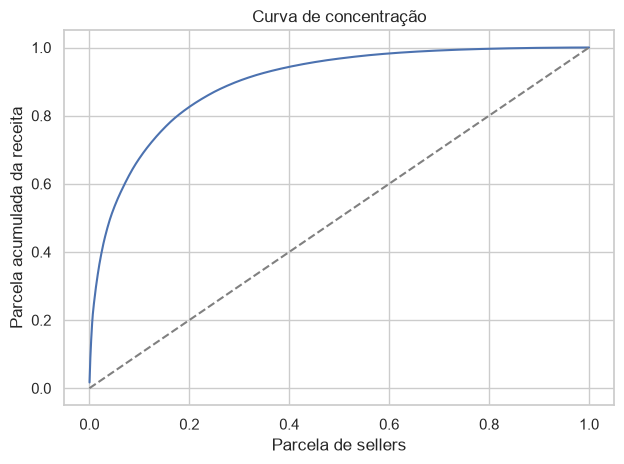

In [10]:
sns.lineplot(x=(sellers.index + 1) / len(sellers), y=sellers.cumulative_share)
plt.plot([0,1],[0,1], '--', color='gray'); plt.xlabel('Parcela de sellers'); plt.ylabel('Parcela acumulada da receita'); plt.title('Curva de concentração'); plt.tight_layout()

In [ ]:
ascending_revenue = np.sort(sellers.revenue.to_numpy())
n = len(ascending_revenue); gini = (2*np.sum(np.arange(1,n+1)*ascending_revenue)/(n*ascending_revenue.sum())) - (n+1)/n
seller_risk = sellers[(sellers.orders >= 30) & sellers.late_rate.notna()].copy()
weighted_late_rate = np.average(seller_risk.late_rate, weights=seller_risk.revenue)
display(pd.Series({'gini_revenue':gini,'HHI':(shares**2).sum(),'revenue_weighted_late_rate':weighted_late_rate,'sellers_with_30plus_orders':len(seller_risk)}).to_frame('value'))

seller_risk.nlargest(10,'revenue')[['seller_id','orders','revenue','avg_review_score','late_rate']]

,value
gini_revenue,0.790655
HHI,0.003595
revenue_weighted_late_rate,0.078960
sellers_with_30plus_orders,634.000000


,seller_id,orders,revenue,avg_review_score,late_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,1131,229237.63,4.125545,0.115854
1,53243585a1d6dc2643021fd1853d8905,358,222776.05,4.075980,0.040000
2,4a3ca9315b744ce9f8e9374361493884,1804,200326.12,3.804082,0.109800
3,fa1c13f2614d7b5c4749cbc52fecda94,584,192842.13,4.344234,0.101900
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,3.341445,0.095941
5,7e93a43ef30c4f03f38b393420bc753a,332,172583.88,4.238806,0.055901
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,4.063754,0.072997
7,7a67c85e85bb2ce8582c35f2203ad736,1159,141715.54,4.235573,0.058874
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,3.853107,0.092254
9,955fee9216a65b617aa5c0531780ce60,1286,135159.70,4.052490,0.080842


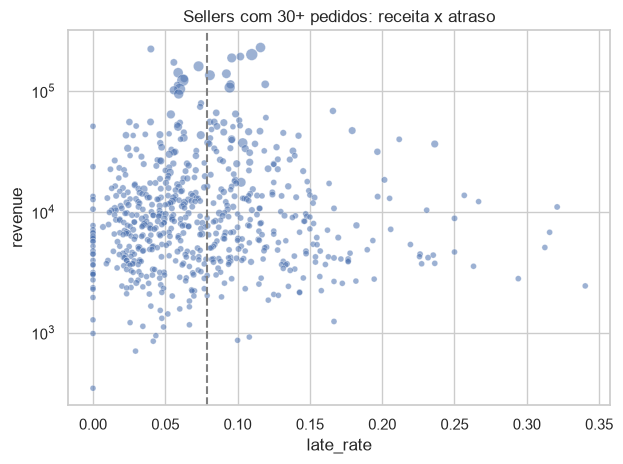

In [73]:
sns.scatterplot(data=seller_risk, x='late_rate', y='revenue', size='orders', alpha=.55, legend=False)
plt.axvline(weighted_late_rate, color='gray', ls='--'); plt.yscale('log'); plt.title('Sellers com 30+ pedidos: receita x atraso'); plt.tight_layout()